In [ ]:
import tarfile
import os
from tqdm import tqdm

import os, glob, math, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **Extract dataset**

In [ ]:
def extract_tar_with_progress(tar_path, output_dir):
    print(f"\nExtracting: {tar_path}\n")
    with tarfile.open(tar_path, "r:") as tar:
        members = tar.getmembers()
        total = len(members)

        for member in tqdm(members, total=total, desc="Extracting", unit="files"):
            tar.extract(member, path=output_dir)

    print("Extraction complete!")

In [ ]:
train_tar = "datasets/trainset.tar"
test_tar  = "datasets/testset.tar"

In [ ]:
extract_root = "causal3DIdent" # Extraction target folder in colab storage
os.makedirs(extract_root, exist_ok=True)

**Run extraction**

In [ ]:

extract_tar_with_progress(train_tar, extract_root)
extract_tar_with_progress(test_tar, extract_root)



Extracting: /content/drive/MyDrive/IUThesis/Implementation/causal3DIdent_dataset/trainset.tar



Extracting:   0%|          | 0/252023 [00:00<?, ?files/s]/tmp/ipython-input-794/2486757066.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=output_dir)
Extracting: 100%|██████████| 252023/252023 [00:33<00:00, 7610.61files/s]


Extraction complete!

Extracting: /content/drive/MyDrive/IUThesis/Implementation/causal3DIdent_dataset/testset.tar



Extracting: 100%|██████████| 25222/25222 [00:03<00:00, 7918.11files/s]

Extraction complete!



# **LOAD DATASET**

We load the Causal3DIdent dataset and turning it into tensors.
The dataset has two parts:

1.   Images
2.   Ground-truth latent vectors (10-dimensional causal factors)

We also pair each image with its corresponding latent vector

In [ ]:
class Causal3DIdentDataset(Dataset):
    def __init__(self, root, image_size=64, return_latent=True):
        self.root = root
        self.return_latent = return_latent

        # Load latent shards (latent vectors)
        latent_files = sorted(glob.glob(os.path.join(root, "latents_*.npy")))
        latents_list = [np.load(f) for f in latent_files]
        self.latents = np.concatenate(latents_list, axis=0)     # concatenate the latents into one large array (N, 10) since each latent has 10 dimensions

        # Load images (from images_0 ... images_6 folders)
        self.image_paths = []
        shard_dirs = sorted(glob.glob(os.path.join(root, "images_*")))
        for folder in shard_dirs:
            files = sorted(glob.glob(os.path.join(folder, "*.png")))
            self.image_paths.extend(files)

        assert len(self.image_paths) == len(self.latents), \
            f"Mismatch {len(self.image_paths)} vs {len(self.latents)}" #Safety Check to ensure images and latents match. It is necesary because each image corresponds correctly to one latent vector.

        # Define image transformations
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)), #Images are resized (we use 64 x 64)
            transforms.ToTensor(), #Converted to tensor with shape (3, 64, 64)
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)

        if self.return_latent:
            lat = self.latents[idx].astype(np.float32)
            return img, torch.from_numpy(lat)
        else:
            return img


**Test/validation splits**

In [ ]:

train_root = "causal3DIdent/trainset"
test_root  = "causal3DIdent/testset"

full_train_ds = Causal3DIdentDataset(train_root, image_size=64, return_latent=True)
test_ds       = Causal3DIdentDataset(test_root,  image_size=64, return_latent=True)

print("Training samples:", len(full_train_ds))
print("Test samples:", len(test_ds))

val_size = int(0.1 * len(full_train_ds)) #Create a validation split (10% of the training dataset)
train_size = len(full_train_ds) - val_size

train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

print("Train:", len(train_ds), "   Val:", len(val_ds))


Training samples: 252000
Test samples: 25200
Train: 226800    Val: 25200


# **CNN Encoder**

| Layer | Layer Type        | Kernel Size | Stride | Padding | Out Channels    |
|-------|-------------------|-------------|--------|---------|-----------------|
| 0     | Input             | –           | –      | –       | 3 (RGB)         |
| 1     | Convolutional     | 5 × 5       | 1      | 2       | 64              |
| 2     | ReLU              | –           | –      | –       | –               |
| 3     | Convolutional     | 5 × 5       | 1      | 2       | 64              |
| 4     | ReLU              | –           | –      | –       | –               |
| 5     | Convolutional     | 5 × 5       | 1      | 2       | 64              |
| 6     | ReLU              | –           | –      | –       | –               |
| 7     | Convolutional     | 5 × 5       | 1      | 2       | 64              |
| 8     | ReLU              | –           | –      | –       | –               |
| 9     | Reshape + Permute | –           | –      | –       | (B, H·W, 64)    |

We use a 5 x 5 convolution kernel is chosen because it provides a larger receptive field compared to 3 x 3 convolutions.
A 5 x 5 kernel sees more of the local neighborhood:


*   3x3 sees 9 pixels
*   5x5 sees 25 pixels

Stride of 1 ensures we move one pixel at a stride (pixel-wise). If we use a stride of 2, then we will skip every other pixel (downsampling).

Since we are using slot attention, slot attention requires:


*   A dense grid of features (one token per pixel)
*   No downsampling
*   Spatial precision for object localization
Therefore stride = 1 preserves spatial resolution and ensures that:
$Output resolution  = input resolution $ (a fundamental requirement for slot attention encoders)









Padding = 2 ensures that a 5×5 convolution produces an output with the same height and width as the input.

Mathematically:
$
\text{Output size} = \frac{W - K + 2P}{S} + 1
$

**For K = 5, P = 2, S = 1:**

$
\frac{W - 5 + 2(2)}{1} + 1 = W
$

So padding keeps the output the same size.

**Why is this choice important?**

Slot Attention expects a fixed spatial grid of features (e.g., 64 x 64 tokens).

If the encoder shrinks the image after each layer, the model would:


*   Lose pixel-level detail
*   weaken segmentation mask accuracy
*   require extra code for resizing

**Therefore, padding = 2 is chosen primarily to preserve resolution.**


**The original slot attention paper uses 4 CNN (encoder) layers**
Each layer has:


*   Kernel size: 5
*   Stride: 1
*   Padding: 2
*   Filters / Channels: 64
*   Activation: ReLU after each conv.

**We followed exactly that**

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
            nn.ReLU(),
        )

    def forward(self, x):
        feats = self.net(x)              # (B = 64 bacthes,C = 3 channels,Height of feature map = 64, Width of feature map = 64): B,C,H,W
        B, C, H, W = feats.shape
        feats = feats.view(B, C, H*W).permute(0,2,1)  # (B,N,C): N = H × W = number of pixels (flattened spatial tokens)
        return feats


The encoder is a CNN that extracts mid-level visual features from the input image while preserving the full spatial resolution.

After the final convolution, the feature map has shape \((B, C, H, W)\), where each spatial location contains a 64-dimensional feature vector. To prepare these features for Slot Attention, the encoder reshapes the tensor into \((B, N, C)\), where $(N = H \times W)$ represents a sequence of spatial tokens.

Each token corresponds to a single pixel location in the feature map. This flattening and permutation step converts the image into a set of per-pixel feature embeddings, which Slot Attention uses to cluster pixels into object-centric representations ("slots").


# **Slot Attention**

In [ ]:
class SlotAttention(nn.Module):
    """
    Slot Attention module (Locatello et al., 2020).

    This module takes a set of input feature embeddings (e.g., flattened CNN features)
    and clusters them into a fixed number of "slots".
    Each slot is intended to represent one object-like component in the scene.

    Args:
        num_slots (int): Number of slots (i.e., number of objects to extract).
        dim (int): Dimensionality of the slot vectors.
        iters (int): Number of iterative attention refinement steps.
        eps (float): Numerical stability factor added to attention weights.
        hidden_dim (int): Hidden dimension used inside the MLP block.

    Forward Input:
        inputs: Tensor of shape (B, N, D)
            B = batch size
            N = number of pixel-level tokens (H*W)
            D = feature dimension

    Forward Output:
        slots: Tensor of shape (B, K, D)
            K = num_slots
            D = slot dimensionality

    Summary of operations per iteration:
        1. Normalize slots and inputs.
        2. Compute Q (from slots) and K/V (from inputs).
        3. Compute attention weights (soft assignment of pixels to slots).
        4. Use attention to aggregate input features into slot updates.
        5. Update slots using a GRU cell.
        6. Apply MLP refinement with residual connection.
    """

    def __init__(self, num_slots, dim, iters=3, eps=1e-8, hidden_dim=128):
        super().__init__()

        # -----------------------------
        # Hyperparameters and constants
        # -----------------------------
        self.num_slots = num_slots
        self.dim = dim
        self.iters = iters
        self.eps = eps
        self.scale = dim ** -0.5  # scaling factor for dot-product attention

        # --------------------------------------
        # Learnable slot initialization parameters
        # slots ~ N(mu, sigma)
        # --------------------------------------
        self.slots_mu = nn.Parameter(torch.randn(1, 1, dim))
        self.slots_log_sigma = nn.Parameter(torch.zeros(1, 1, dim))

        # -----------------------
        # Linear projections Q/K/V
        # -----------------------
        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)

        # -----------------------
        # Recurrent slot updater
        # -----------------------
        self.gru = nn.GRUCell(dim, dim)

        # -----------------------
        # MLP for slot refinement
        # -----------------------
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim),
        )

        # ----------------------------
        # Normalization layers
        # ----------------------------
        self.norm_input = nn.LayerNorm(dim)
        self.norm_slots = nn.LayerNorm(dim)
        self.norm_pre_ff = nn.LayerNorm(dim)

    def forward(self, inputs):
        """
        Args:
            inputs: Tensor (B, N, D) → a set of per-pixel feature embeddings

        Returns:
            slots: Tensor (B, K, D) → object-centric representations
        """

        B, N, D = inputs.shape
        K = self.num_slots

        # =====================================================
        # (1) Normalize input tokens to stabilize attention
        # =====================================================
        inputs = self.norm_input(inputs)

        # =====================================================
        # (2) Initialize slots from learnable Gaussian distribution
        # =====================================================
        mu = self.slots_mu.expand(B, K, -1)
        sigma = torch.exp(self.slots_log_sigma).expand(B, K, -1)
        slots = mu + sigma * torch.randn_like(mu)  # shape: (B, K, D)

        # Project encoded inputs to keys and values once (constant per iteration)
        k = self.to_k(inputs)  # shape: (B, N, D)
        v = self.to_v(inputs)  # shape: (B, N, D)

        # =====================================================
        # Iterative attention + GRU refinement
        # =====================================================
        for _ in range(self.iters):

            # -----------------------------
            # Keep copy of previous slots
            # -----------------------------
            slots_prev = slots

            # -----------------------------
            # Normalize slots for numerical stability
            # -----------------------------
            slots_norm = self.norm_slots(slots)

            # -----------------------------
            # Compute queries from slots: shape (B, K, D)
            # -----------------------------
            q = self.to_q(slots_norm)

            # -----------------------------
            # Dot-product attention: QK^T
            # Shape: (B, K, N)
            # -----------------------------
            attn_logits = torch.einsum("bid,bjd->bij", q, k) * self.scale

            # -----------------------------
            # Softmax over slots (K dimension)
            # Pixels choose which slot explains them
            # -----------------------------
            attn = attn_logits.softmax(dim=1) + self.eps

            # Re-normalize attention weights so columns sum to 1
            attn = attn / attn.sum(dim=-1, keepdim=True)

            # -----------------------------
            # Weighted aggregation of pixel embeddings
            # Shape: (B, K, D)
            # -----------------------------
            updates = torch.einsum("bjd,bij->bid", v, attn)

            # -----------------------------
            # GRU update per slot
            # (flatten batch & slot dims for GRUCell)
            # -----------------------------
            slots = self.gru(
                updates.reshape(-1, D),        # input
                slots_prev.reshape(-1, D)      # hidden state
            )
            slots = slots.reshape(B, K, D)

            # -----------------------------
            # MLP refinement with residual connection
            # -----------------------------
            slots = slots + self.mlp(self.norm_pre_ff(slots))


        # Return final object-centric slots
        return slots


# **Spatial broadcast decoder**

In [ ]:
class SpatialBroadcastDecoder(nn.Module):
    """
    Spatial Broadcast Decoder (SBD) used in Slot Attention Autoencoders.

    This decoder takes each slot vector (object representation) and expands it
    into a spatial feature map by:
        1. Broadcasting the slot across a small spatial grid (8×8).
        2. Using a stack of ConvTranspose2D layers to upsample it back to
           the full image resolution.
        3. Producing both:
              - RGB appearance for each slot
              - An alpha mask per slot (soft attention mask)

    The final reconstructed image is obtained by alpha-compositing the RGB
    predictions of each slot weighted by its mask.

    Args:
        slot_dim (int): Dimensionality of each slot vector.
        hidden_dim (int): Number of channels in the decoder’s hidden layers.
        out_channels (int): Number of output RGB channels (typically 3).
        resolution (int): Output image resolution (e.g., 64 → 64×64 images).

    Forward Input:
        slots: Tensor of shape (B, K, D)
            B = batch size
            K = number of slots
            D = slot dimension

    Forward Output:
        recon: Tensor (B, 3, H, W)
            Final reconstructed image.

        masks: Tensor (B, K, 1, H, W)
            Soft alpha masks representing how much each slot contributes
            at each pixel location.
    """

    def __init__(self, slot_dim, hidden_dim=64, out_channels=3, resolution=64):
        super().__init__()
        self.resolution = resolution

        # Initial small spatial grid size (8x8)-
        self.init_res = 8

        # Project slot vector → initial spatial grid
        # Produces feature maps of shape (hidden_dim, 8, 8)
        self.fc = nn.Linear(slot_dim, hidden_dim * self.init_res * self.init_res)

        # Upsampling stages using ConvTranspose2D
        # Each layer doubles spatial resolution
        # 8 → 16 → 32 → 64
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim, hidden_dim, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(hidden_dim, hidden_dim, 4, stride=2, padding=1),
            nn.ReLU(),

            # Final layer outputs:
            #   (out_channels + 1)
            #   last channel = alpha mask
            nn.ConvTranspose2d(hidden_dim, out_channels + 1, 4, stride=2, padding=1),
        )

    def forward(self, slots):
        """
        Args:
            slots: Tensor (B, K, D)
                Object-centric slot vectors.

        Returns:
            recon: (B, 3, H, W) reconstructed image
            masks: (B, K, 1, H, W) soft per-slot masks
        """

        B, K, D = slots.shape
        H = W = self.resolution

        # ============================================================
        # (1) Convert each slot to an 8×8 spatial grid via linear layer
        # Produces tensor: (B*K, hidden_dim, 8, 8)
        # ============================================================
        x = self.fc(slots)                              # (B, K, hidden*8*8)
        x = x.view(B * K, -1, self.init_res, self.init_res)

        # ============================================================
        # (2) Upsample grid to full resolution using ConvTranspose layers
        # ============================================================
        x = self.dec(x)                                 # (B*K, out_channels+1, H, W)

        # Reshape back into slot dimension: (B, K, C+1, H, W)
        x = x.view(B, K, -1, H, W)

        # Split RGB and alpha mask
        rgb = x[:, :, :3]                               # (B, K, 3, H, W)
        alpha = x[:, :, 3:]                             # (B, K, 1, H, W)

        # ============================================================
        # (3) Normalize alpha masks across slots
        # Ensures masks form a soft partition of the image
        # ============================================================
        masks = alpha.softmax(dim=1)                    # (B, K, 1, H, W)

        # ============================================================
        # (4) Weighted sum of slot RGBs using their masks
        # Produces final composite reconstruction
        # ============================================================
        recon = torch.sum(rgb * masks, dim=1)           # (B, 3, H, W)

        return recon, masks


# **Full Slot Attention Autoencoder**

The Slot Attention Autoencoder maps an input image into a small set of **object-centric latent vectors** (“slots”) and reconstructs the image from them.

The encoder converts the image into per-pixel feature embeddings, which the Slot Attention module clusters into a fixed number of slots.
Each slot captures one object or coherent region in the scene.
The spatial broadcast decoder then expands each slot into an RGB layer with a soft mask, and all layers are composited to form the final reconstruction.

 **encode → attend (discover objects) → decode (reconstruct using slots).**


In [ ]:
class SlotAttentionAE(nn.Module):
    def __init__(self, num_slots=4, slot_dim=64, resolution=64):
        super().__init__()

        self.encoder = ConvEncoder(3, 64) # CNN encoder that extracts per-pixel feature embeddings

        self.project = nn.Linear(64, slot_dim) # Project encoder features to slot dimensionality

        self.slot_attention = SlotAttention(num_slots, slot_dim, iters=3) # Slot Attention module. It groups pixel features into K slots

        self.decoder = SpatialBroadcastDecoder(slot_dim, 64, 3, resolution) # Decoder that reconstructs the image from slot representations

    def forward(self, x):

        feats = self.encoder(x)  # Encode input image into spatial feature embeddings

        feats = self.project(feats) # Map features to the slot representation space

        slots = self.slot_attention(feats) # Generate object-centric slot vectors

        recon, masks = self.decoder(slots)  # Decode slots into RGB reconstruction + slot masks

        return recon, slots, masks


In [ ]:
model = SlotAttentionAE(num_slots=4, slot_dim=64, resolution=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

**Training Loop**

In [ ]:
train_losses = []
val_losses = []


In [ ]:
def run_epoch(loader, model, optimizer, train=True, device='cuda'):
    model.train(train)
    total = 0
    loss_sum = 0.0

    # create progress bar
    pbar = tqdm(loader, desc="Training" if train else "Validation", leave=False)

    for imgs, _ in pbar:
        imgs = imgs.to(device)

        if train:
            optimizer.zero_grad()

        recon, slots, masks = model(imgs)
        loss = F.mse_loss(recon, imgs)

        if train:
            loss.backward()
            optimizer.step()

        # update counters
        loss_sum += loss.item() * imgs.size(0)
        total += imgs.size(0)

        # update progress bar text
        pbar.set_postfix(loss=loss.item())

    return loss_sum / total





In [ ]:
# Directory for saving checkpoints
checkpoint_dir = "SlotAttentionCheckpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
num_epochs = 50

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}")

    # ---- Training ----
    train_loss = run_epoch(train_loader, model, optimizer, train=True, device=device)
    train_losses.append(train_loss)      # <-- TRACK TRAIN LOSS

    # ---- Validation ----
    val_loss   = run_epoch(val_loader, model, optimizer, train=False, device=device)
    val_losses.append(val_loss)          # <-- TRACK VAL LOSS

    print(f"Epoch {epoch:02d} — Train {train_loss:.6f} | Val {val_loss:.6f}")

    # SAVE CHECKPOINT EVERY 10 EPOCHS
    if epoch % 10 == 0:
        ckpt_path = f"{checkpoint_dir}/slot_attention_epoch_{epoch}.pth"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss
        }, ckpt_path)
        print(f"Saved checkpoint at: {ckpt_path}")


Epoch 1


Epoch 01 — Train 0.006847 | Val 0.004328

Epoch 2


Epoch 02 — Train 0.003548 | Val 0.003087

Epoch 3


Epoch 03 — Train 0.002864 | Val 0.002643

Epoch 4


Epoch 04 — Train 0.002485 | Val 0.002414

Epoch 5


...

Epoch 46 — Train 0.000995 | Val 0.001012

Epoch 47


Epoch 47 — Train 0.000990 | Val 0.001026

Epoch 48


Epoch 48 — Train 0.000986 | Val 0.000990

Epoch 49


Epoch 49 — Train 0.000978 | Val 0.000979

Epoch 50


Epoch 50 — Train 0.000976 | Val 0.000999
Saved checkpoint at: /content/drive/MyDrive/IUThesis/Implementation/SlotAttentionCheckpoints/slot_attention_epoch_50.pth


## **Load a trained checkpoint**

In [ ]:
checkpoint_path = "SlotAttentionCheckpoints/slot_attention_epoch_50.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model = SlotAttentionAE(num_slots=4, slot_dim=64, resolution=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
model.eval()


Loaded checkpoint from epoch: 50


SlotAttentionAE(
  (encoder): ConvEncoder(
    (net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (7): ReLU()
    )
  )
  (project): Linear(in_features=64, out_features=64, bias=True)
  (slot_attention): SlotAttention(
    (to_q): Linear(in_features=64, out_features=64, bias=False)
    (to_k): Linear(in_features=64, out_features=64, bias=False)
    (to_v): Linear(in_features=64, out_features=64, bias=False)
    (gru): GRUCell(64, 64)
    (mlp): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
    (norm_input): LayerNorm((64,), eps=1e-05, elementw

# **Visualization of Slots, Masks & Reconstruction**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_slots(model, dataset, num_images=3):
    model.eval()

    for i in range(num_images):
        img, _ = dataset[i]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            recon, slot_vecs, masks = model(img)

        img_np = img[0].permute(1,2,0).cpu().numpy()
        recon_np = recon[0].permute(1,2,0).cpu().numpy()

        num_slots = slot_vecs.shape[1]

        plt.figure(figsize=(10, 4 + num_slots * 2))

        # Input image
        plt.subplot(num_slots + 1, 2, 1)
        plt.imshow(img_np)
        plt.title("Input")
        plt.axis("off")

        # Reconstruction
        plt.subplot(num_slots + 1, 2, 2)
        plt.imshow(recon_np)
        plt.title("Reconstruction")
        plt.axis("off")

        # Slot masks + vector bars
        for s in range(num_slots):

            # Mask visualization
            mask = masks[0, s].permute(1,2,0).cpu().numpy()
            mask_rgb = np.repeat(mask, 3, axis=2)

            plt.subplot(num_slots + 1, 2, 2*(s+1) + 1)
            plt.imshow(mask_rgb, cmap='gray')
            plt.title(f"Slot {s+1} — Mask")
            plt.axis("off")

            vec = slot_vecs[0, s].cpu().numpy()  # Slot vector bar plot

            plt.subplot(num_slots + 1, 2, 2*(s+1) + 2)
            plt.bar(np.arange(len(vec)), vec)
            plt.title(f"Slot {s+1} — Latent Vector (dim=64)")
            plt.tight_layout()

        plt.show()


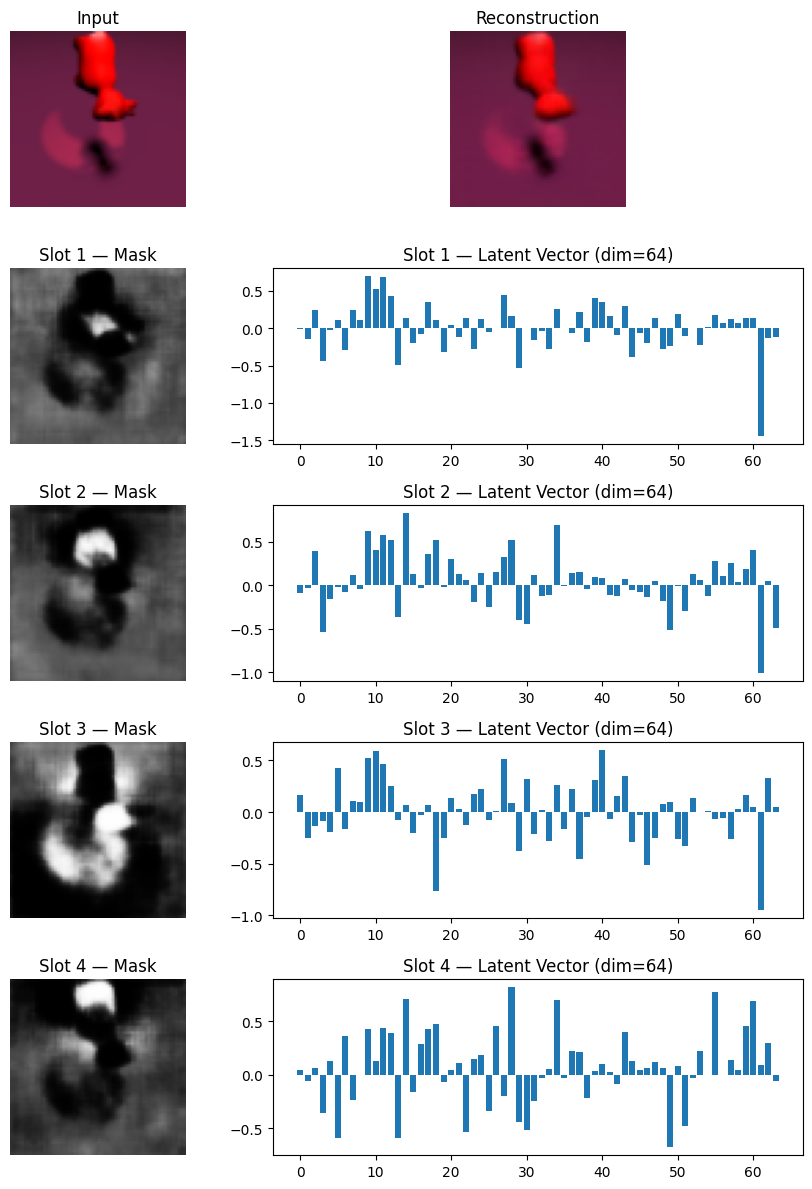

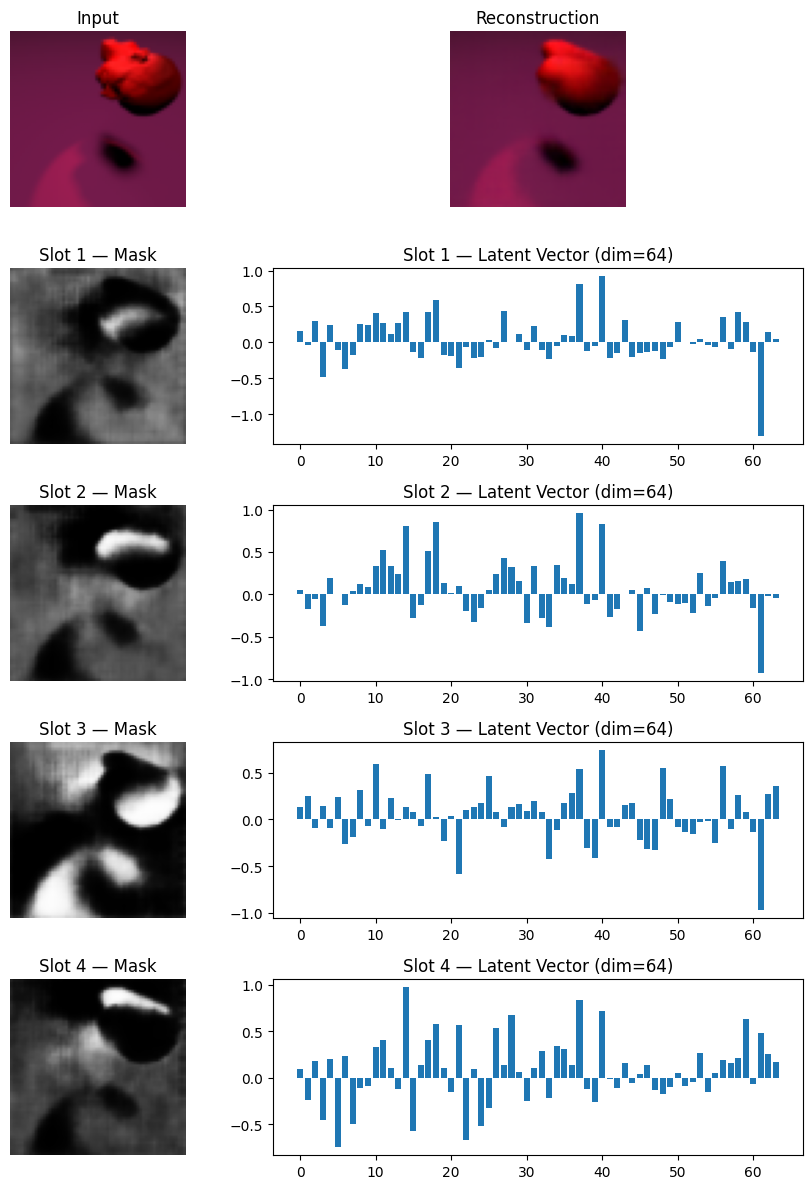

In [ ]:
visualize_slots(model, train_ds, num_images=2)



**1. Reconstruction quality**

The reconstructed image closely matches the input, meaning the model has learned a meaningful latent representation; confirming that:

*   The encoder extracts useful spatial features
*   The Slot Attention module forms stable slot vectors
*   The decoder correctly composites the slot outputs.

**2. Each slot attends to different parts of the scene**

The slot masks highlight how responsibility for the image is divided among slots:
- Bright areas in a mask indicate pixels that the slot is strongly responsible for.
- Dark areas indicate low attention from that slot.

Across the slots:
- One slot focuses on the main object (e.g., the orange shape).
- Other slots focus on shadows, background regions, or light reflections.
- Some slots capture residual image structure that ensures accurate reconstruction.

This soft decomposition is typical: the model learns a factorized view of the scene even when the factors overlap.

**3. Latent vectors encode different scene attributes**

Each slot produces a 64-dimensional latent vector.

The bar plots show that:
- Different slots activate different subsets of dimensions.
- Each latent dimension responds to specific visual factors, such as
  - object shape
  - object color
  - 3D position (x, y, z)
  - lighting and shadows
  - background color

This aligns with the ground-truth generative factors and shows that the model learns structured representations.

**4. Slot specialization is visible**

Although the masks are not perfectly separated (which is expected), the slots show a "division of labor":
- One slot focuses on the foreground object.
- One or two slots capture shadows and floor reflections.
- Another slot captures the broader background tone.


**Conclusion**

The results demonstrate that the model:
- reconstructs the scene well,
- assigns different image regions to different slots,
- learns latent vectors that vary meaningfully with scene factors, and
- produces object-centric representations aligned with the dataset's structure.

These results confirm that the model is successfully learning object-aware, and latent representations.


# **Visualizations of the training and validation**

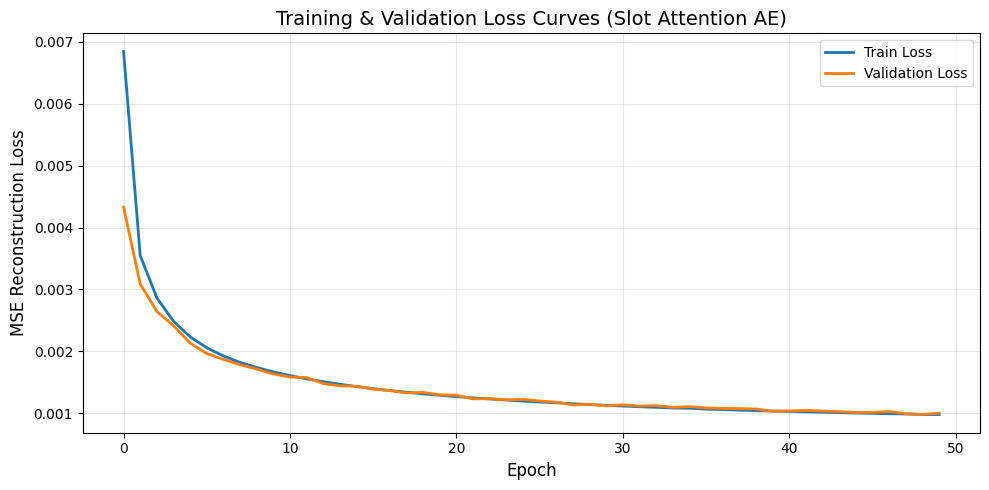

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Reconstruction Loss", fontsize=12)
plt.title("Training & Validation Loss Curves (Slot Attention AE)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# **Hungarian-matched slot invariance**

In [ ]:
def add_gaussian_noise(imgs, sigma=0.05):
    noisy = imgs + sigma * torch.randn_like(imgs)
    return torch.clamp(noisy, 0.0, 1.0)

@torch.no_grad()
def hungarian_match_slots(slots_a, slots_b, metric="l2"):
    """
    slots_a, slots_b: (B, K, D)
    Returns:
      matched_dist: (B, K)  distance per matched slot
      perm: (B, K) indices in b matched to each slot in a
    """
    assert slots_a.shape == slots_b.shape
    B, K, D = slots_a.shape

    matched_dist = []
    perms = []

    for b in range(B):
        A = slots_a[b]  # (K,D)
        Bslots = slots_b[b]  # (K,D)

        # cost matrix C[i,j] = dist(A_i, B_j)
        if metric == "l2":
            # (K,K)
            C = torch.cdist(A.unsqueeze(0), Bslots.unsqueeze(0), p=2).squeeze(0)
        elif metric == "l1":
            C = torch.cdist(A.unsqueeze(0), Bslots.unsqueeze(0), p=1).squeeze(0)
        else:
            raise ValueError("metric must be 'l2' or 'l1'")

        # Hungarian on CPU numpy
        row_ind, col_ind = linear_sum_assignment(C.detach().cpu().numpy())

        # row_ind is [0..K-1] usually, col_ind gives assignment
        col_ind = torch.tensor(col_ind, device=slots_a.device, dtype=torch.long)

        # distances for matched pairs in the order of slots_a
        d = C[torch.arange(K, device=slots_a.device), col_ind]  # (K,)
        matched_dist.append(d)
        perms.append(col_ind)

    matched_dist = torch.stack(matched_dist, dim=0)  # (B,K)
    perms = torch.stack(perms, dim=0)                # (B,K)
    return matched_dist, perms


@torch.no_grad()
def matched_slot_invariance_under_noise(model, loader, noise_sigma=0.05,
                                       num_batches=20, metric="l2", device="cuda"):
    """
    Computes Hungarian-matched slot distance between clean vs noisy images.

    Returns:
      all_mean_per_image: (N_images,) mean matched distance per image
      all_per_slot: (N_images, K) matched distance per slot
    """
    model.eval()
    per_image_means = []
    per_image_slots = []

    for b_idx, (imgs, _) in enumerate(tqdm(loader, desc="Matched slot invariance", total=num_batches)):
        if b_idx >= num_batches:
            break

        imgs = imgs.to(device)

        # forward clean
        _, slots_clean, _ = model(imgs)           # (B,K,D)

        # forward noisy
        imgs_noisy = add_gaussian_noise(imgs, sigma=noise_sigma)
        _, slots_noisy, _ = model(imgs_noisy)    # (B,K,D)

        # Hungarian match
        dist, _ = hungarian_match_slots(slots_clean, slots_noisy, metric=metric)  # (B,K)

        per_image_slots.append(dist.detach().cpu())
        per_image_means.append(dist.mean(dim=1).detach().cpu())  # mean over K slots -> (B,)

    all_per_slot = torch.cat(per_image_slots, dim=0).numpy()  # (N,K)
    all_mean = torch.cat(per_image_means, dim=0).numpy()      # (N,)
    return all_mean, all_per_slot

In [ ]:
#Hungarian-matched invariance under noise on VAL (or TEST)
noise_sigma = 0.05
num_batches = 30    # adjust as needed

mean_dist, per_slot_dist = matched_slot_invariance_under_noise(
    model=model,
    loader=val_loader,
    noise_sigma=noise_sigma,
    num_batches=num_batches,
    metric="l2",
    device=device
)

print("\n===============================")
print(" Hungarian-matched slot invariance (noise)")
print("===============================")
print(f"Noise sigma: {noise_sigma}")
print(f"Num samples (approx): {len(mean_dist)} images")
print(f"Mean matched distance (avg over images): {mean_dist.mean():.6f}")
print(f"Std  matched distance: {mean_dist.std():.6f}")

print("\nPer-slot mean distances (averaged over images):")
print(np.round(per_slot_dist.mean(axis=0), 6))

Matched slot invariance: 100%|██████████| 30/30 [00:06<00:00,  4.51it/s]


 Hungarian-matched slot invariance (noise)
Noise sigma: 0.05
Num samples (approx): 1920 images
Mean matched distance (avg over images): 2.404027
Std  matched distance: 0.497891

Per-slot mean distances (averaged over images):
[2.41535  2.411756 2.384494 2.404506]


The Hungarian-matched slot invariance under noise measures how much slot representations change when small noise (σ = 0.05) is added to the image, using Hungarian matching to compare slots correctly.

The mean is the average change in slot vectors (L2 distance) while the standard deviation is the Variation across images.

Per-slot means show that all slots change similarly.

Small image noise causes large changes in slot representations. Therefore, baseline Slot Attention is sensitive to perturbations.

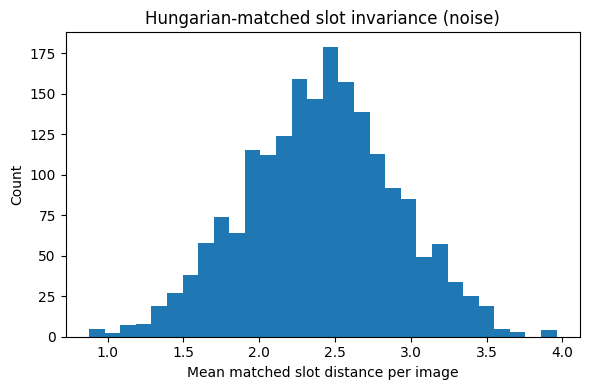

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(mean_dist, bins=30)
plt.xlabel("Mean matched slot distance per image")
plt.ylabel("Count")
plt.title("Hungarian-matched slot invariance (noise)")
plt.tight_layout()
plt.show()

The histogram shows how much the slot representations change when small noise is added to the image.

Most images have a matched slot distance around 2.4, meaning the slot vectors move a lot even for small pixel noise.

In [ ]:
@torch.no_grad()
def matched_slot_distance_same_image_two_passes(model, loader, num_batches=20, metric="l2", device="cuda"):
    model.eval()
    per_image_means = []

    for b_idx, (imgs, _) in enumerate(tqdm(loader, desc="Init-noise floor", total=num_batches)):
        if b_idx >= num_batches:
            break
        imgs = imgs.to(device)

        # two forward passes on same imgs
        _, s1, _ = model(imgs)
        _, s2, _ = model(imgs)

        dist, _ = hungarian_match_slots(s1, s2, metric=metric)
        per_image_means.append(dist.mean(dim=1).cpu())

    return torch.cat(per_image_means, dim=0).numpy()

same_pass_dist = matched_slot_distance_same_image_two_passes(model, val_loader, num_batches=30, device=device)

print("\n=== Init-noise floor (same image, two passes) ===")
print("Mean:", same_pass_dist.mean())
print("Std :", same_pass_dist.std())

print("\nRatio (noise / init_floor):", mean_dist.mean() / (same_pass_dist.mean() + 1e-8))

Init-noise floor: 100%|██████████| 30/30 [00:05<00:00,  5.44it/s]


=== Init-noise floor (same image, two passes) ===
Mean: 0.17491156
Std : 0.114367716

Ratio (noise / init_floor): 13.744241


The initialization noise floor quantifies the variability of slot representations when the same image is passed through the model twice. The mean distance is small, indicating that stochastic slot initialization introduces minimal variation. The large noise-to-initialization ratio shows that input perturbations cause substantially greater changes in slot representations than random initialization effects.

In [ ]:
@torch.no_grad()
def matched_relative_change(model, loader, noise_sigma=0.05, num_batches=20, metric="l2", device="cuda"):
    model.eval()
    rels = []

    for b_idx, (imgs, _) in enumerate(tqdm(loader, desc="Relative change", total=num_batches)):
        if b_idx >= num_batches:
            break

        imgs = imgs.to(device)
        _, s, _ = model(imgs)

        imgs_noisy = add_gaussian_noise(imgs, sigma=noise_sigma)
        _, s_noisy, _ = model(imgs_noisy)

        dist, perm = hungarian_match_slots(s, s_noisy, metric=metric)  # (B,K)

        # matched norms: ||s|| for each slot in s, corresponding matched slot in s_noisy
        s_norm = torch.norm(s, dim=-1)  # (B,K)
        rel = dist / (s_norm + 1e-8)
        rels.append(rel.mean(dim=1).cpu())  # per-image

    return torch.cat(rels, dim=0).numpy()

rel_change = matched_relative_change(model, val_loader, noise_sigma=0.05, num_batches=30, device=device)
print("\n=== Relative matched change ===")
print("Mean:", rel_change.mean())
print("Std :", rel_change.std())

Relative change: 100%|██████████| 30/30 [00:05<00:00,  5.38it/s]


=== Relative matched change ===
Mean: 0.9364749
Std : 0.20364954


The relative matched change measures the normalized difference between clean and noisy slot representations, computed as the matched L2 distance divided by the slot norm. A mean value close to 1 indicates that the magnitude of slot representations changes substantially under small input perturbations. This confirms high sensitivity of the baseline model to noise.